<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science-Ml/blob/main/Exchange_Assignment%5B19%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Forecasting Exchange Rates Using Time Series Analysis

# Part 1 – Data Preparation and Exploration


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt

from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
file_path = "exchange_rate.csv"
data = pd.read_csv(file_path)

# Parse dates
data["date"] = pd.to_datetime(data["date"], dayfirst=True, errors="coerce")
data["Ex_rate"] = pd.to_numeric(data["Ex_rate"], errors="coerce")

# Sort chronologically and remove duplicate dates if any
data = data.sort_values("date").drop_duplicates("date").reset_index(drop=True)

# Set date as index
ts = data.set_index("date")["Ex_rate"].asfreq("D")

print("Shape:", data.shape)
display(data.head())
display(data.tail())


Shape: (7588, 2)


,date,Ex_rate
0,1990-01-01,0.7855
1,1990-01-02,0.7818
2,1990-01-03,0.7867
3,1990-01-04,0.7860
4,1990-01-05,0.7849


,date,Ex_rate
7583,2010-10-06,0.718494
7584,2010-10-07,0.721839
7585,2010-10-08,0.723197
7586,2010-10-09,0.720825
7587,2010-10-10,0.720825


## 1.2 Initial exploration

I check:
- data types,
- date range,
- missing values,
- duplicate dates,
- summary statistics,
- and whether the time series has suspicious values.


In [2]:
print("Data types:")
display(data.dtypes.to_frame("Data Type"))

print("Date range:")
print(ts.index.min(), "to", ts.index.max())

print("\nMissing values:")
display(data.isna().sum().to_frame("Missing Count"))

print("\nMissing values after daily frequency:")
print(ts.isna().sum())

print("\nDuplicate dates:", data["date"].duplicated().sum())

print("\nSummary statistics:")
display(ts.describe().to_frame("Ex_rate"))


Data types:


,Data Type
date,datetime64[ns]
Ex_rate,float64


Date range:
1990-01-01 00:00:00 to 2010-10-10 00:00:00

Missing values:


,Missing Count
date,0
Ex_rate,0



Missing values after daily frequency:
0

Duplicate dates: 0

Summary statistics:


,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


## 1.3 Handle missing values

The original CSV does not contain missing values in either column. After converting the series to a daily frequency, I check again because ` can reveal missing calendar dates.

If missing observations exist, I use time interpolation for the exchange-rate series. This is reasonable for a continuously observed financial time series because the missing value is estimated from neighbouring dates rather than replacing the entire series with one constant value.


In [3]:
missing_before = ts.isna().sum()

if missing_before > 0:
    ts = ts.interpolate(method="time").ffill().bfill()

print("Missing observations before handling:", missing_before)
print("Missing observations after handling:", ts.isna().sum())


Missing observations before handling: 0
Missing observations after handling: 0


## 1.4 Plot the exchange-rate time series

Asks for a time-series plot to understand trend, seasonality and anomalies.

The full historical plot gives the overall movement, while a shorter recent-period plot makes local behaviour easier to see.


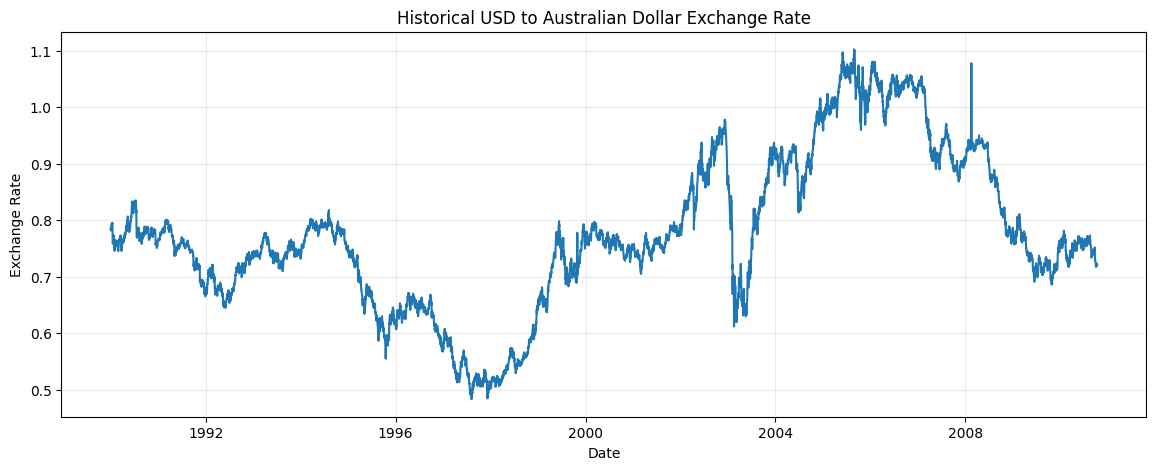

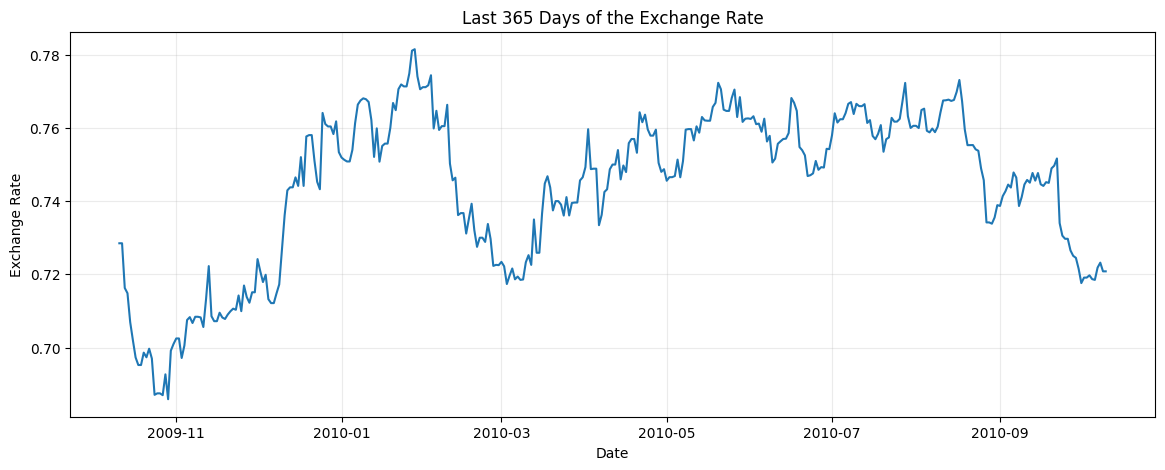

In [4]:
plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts.values)
plt.title("Historical USD to Australian Dollar Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(ts.tail(365).index, ts.tail(365).values)
plt.title("Last 365 Days of the Exchange Rate")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.grid(alpha=0.25)
plt.show()


## 1.5 Check for possible anomalies/outliers

I use a rolling median and rolling standard deviation as an exploratory diagnostic. Large deviations are flagged for inspection rather than automatically deleted.

For financial exchange-rate data, an extreme movement may be a genuine market event, so removing observations without evidence of a data-entry error would be inappropriate.


Potential large deviations from 30-day rolling behaviour: 2


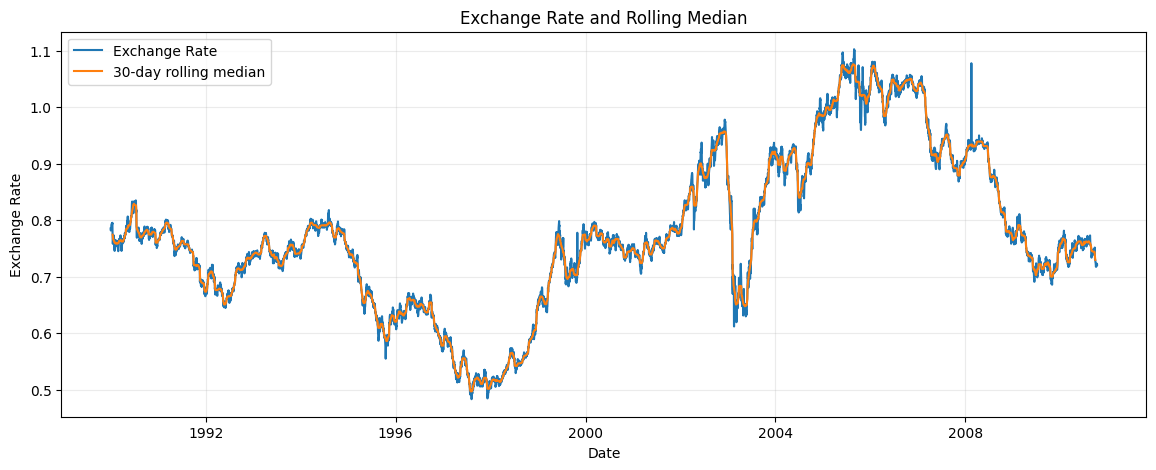

In [5]:
rolling_median = ts.rolling(window=30, center=True).median()
rolling_std = ts.rolling(window=30, center=True).std()

z_like = (ts - rolling_median) / rolling_std.replace(0, np.nan)
anomaly_count = (z_like.abs() > 4).sum()

print("Potential large deviations from 30-day rolling behaviour:", int(anomaly_count))

plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts.values, label="Exchange Rate")
plt.plot(rolling_median.index, rolling_median.values, label="30-day rolling median")
plt.title("Exchange Rate and Rolling Median")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# Part 2 – ARIMA Model

## 2.1 Stationarity and differencing

ARIMA uses:
- `p` = autoregressive order,
- `d` = degree of differencing,
- `q` = moving-average
Ask to use ACF and PACF to estimate initial parameters. Before using these plots, I check stationarity with the Augmented Dickey-Fuller (ADF) test.

The null hypothesis of the ADF test is that the series has a unit root (is non-stationary).


In [6]:
def adf_report(series, name):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"ADF test for {name}")
    print("ADF statistic:", round(result[0], 6))
    print("p-value:", round(result[1], 6))
    print("Used lags:", result[2])
    print("Observations:", result[3])
    print("5% critical value:", round(result[4]["5%"], 6))

adf_report(ts, "Original Exchange Rate")

diff1 = ts.diff().dropna()
adf_report(diff1, "First Difference")


ADF test for Original Exchange Rate
ADF statistic: -1.664994
p-value: 0.449233
Used lags: 1
Observations: 7586
5% critical value: -2.861921
ADF test for First Difference
ADF statistic: -99.393431
p-value: 0.0
Used lags: 0
Observations: 7586
5% critical value: -2.861921


## 2.2 ACF and PACF plots

I plot ACF and PACF for the first-differenced series.

These plots are used to suggest a starting range for `p` and `q`. I then compare nearby ARIMA specifications using AIC rather than treating one visual cutoff as a guaranteed answer.


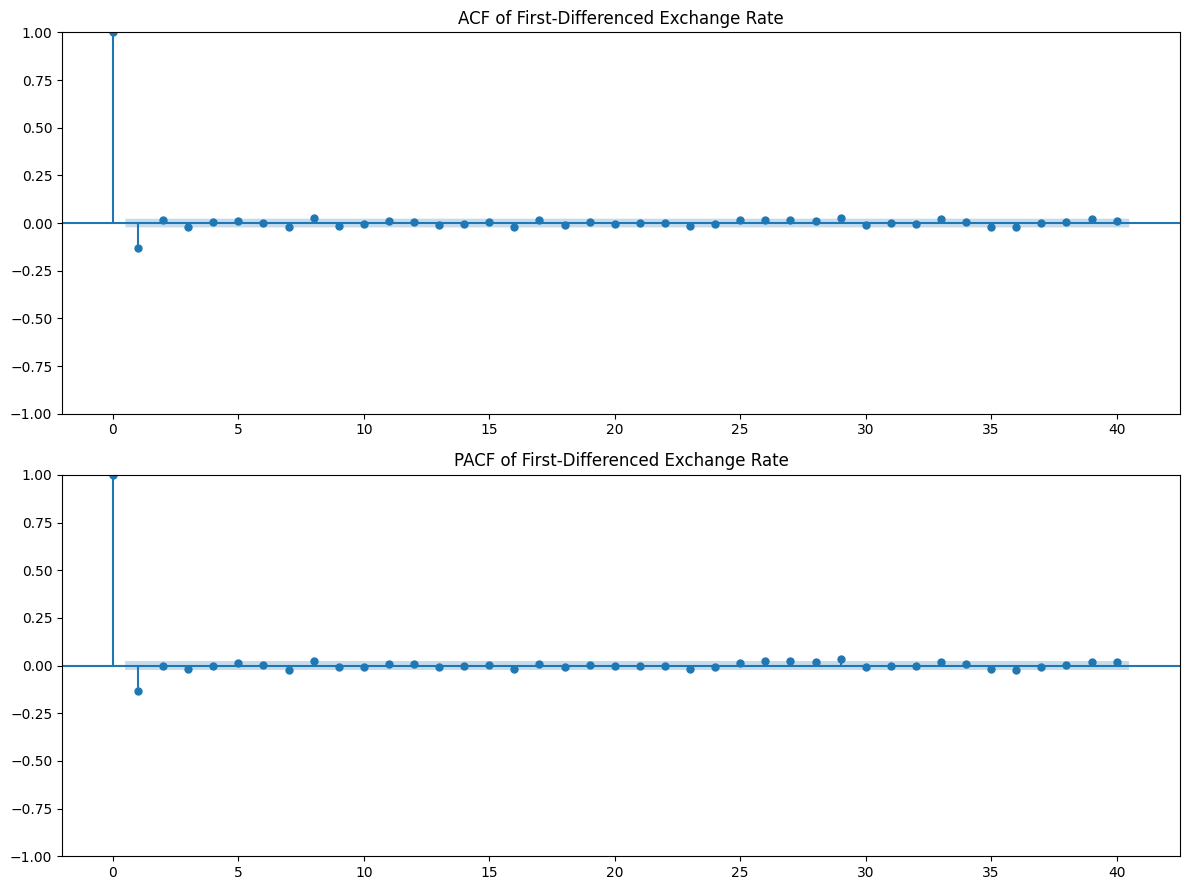

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

plot_acf(diff1, lags=40, ax=axes[0])
axes[0].set_title("ACF of First-Differenced Exchange Rate")

plot_pacf(diff1, lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF of First-Differenced Exchange Rate")

plt.tight_layout()
plt.show()


## 2.3 ARIMA parameter search

Based on the ACF/PACF plots, I test a small grid around low-order AR and MA terms with `d = 1`.

The model with the lowest AIC is selected from the tested combinations. This provides a reproducible way to support the parameter choice.


In [8]:
candidate_orders = []

for p in range(0, 4):
    for d in [1]:
        for q in range(0, 4):
            candidate_orders.append((p, d, q))

arima_results = []

for order in candidate_orders:
    try:
        model = ARIMA(ts, order=order)
        fitted = model.fit()
        arima_results.append({
            "Order": order,
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })
    except Exception:
        pass

arima_results = pd.DataFrame(arima_results).sort_values("AIC").reset_index(drop=True)

display(arima_results.head(10).round(4))

best_order = tuple(arima_results.iloc[0]["Order"])
print("Selected ARIMA order:", best_order)


,Order,AIC,BIC
0,"(2, 1, 3)",-56105.1554,-56063.5502
1,"(1, 1, 0)",-56104.3189,-56090.4505
2,"(0, 1, 1)",-56102.7534,-56088.8850
3,"(3, 1, 0)",-56102.4032,-56074.6664
4,"(1, 1, 1)",-56102.3217,-56081.5191
5,"(2, 1, 0)",-56102.3210,-56081.5184
6,"(0, 1, 3)",-56102.2820,-56074.5452
7,"(0, 1, 2)",-56101.8642,-56081.0617
8,"(1, 1, 2)",-56101.5910,-56073.8542
9,"(3, 1, 1)",-56100.4025,-56065.7315


Selected ARIMA order: (2, 1, 3)


## 2.4 Fit the selected ARIMA model

I fit the selected ARIMA specification on the training data only. The last part of the series is kept as an out-of-sample test set so that forecasting performance can be measured honestly.


In [9]:
# Hold out the last 20% for out-of-sample evaluation
test_size = int(len(ts) * 0.20)

train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Train period:", train.index.min(), "to", train.index.max())
print("Test period:", test.index.min(), "to", test.index.max())

arima_model = ARIMA(train, order=best_order)
arima_fit = arima_model.fit()

print(arima_fit.summary())


Training observations: 6071
Testing observations: 1517
Train period: 1990-01-01 00:00:00 to 2006-08-15 00:00:00
Test period: 2006-08-16 00:00:00 to 2010-10-10 00:00:00
                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6071
Model:                 ARIMA(2, 1, 3)   Log Likelihood               22728.317
Date:                Wed, 26 Aug 2026   AIC                         -45444.633
Time:                        14:44:37   BIC                         -45404.367
Sample:                    01-01-1990   HQIC                        -45430.658
                         - 08-15-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7242      0.094     -7.66

## 2.5 ARIMA residual diagnostics

A good time-series model should leave residuals that behave approximately like white noise.

I inspect:
- residual time plot,
- residual histogram,
- residual ACF,
- and the Ljung-Box test.

A significant Ljung-Box p-value would suggest remaining autocorrelation and possible model inadequacy.


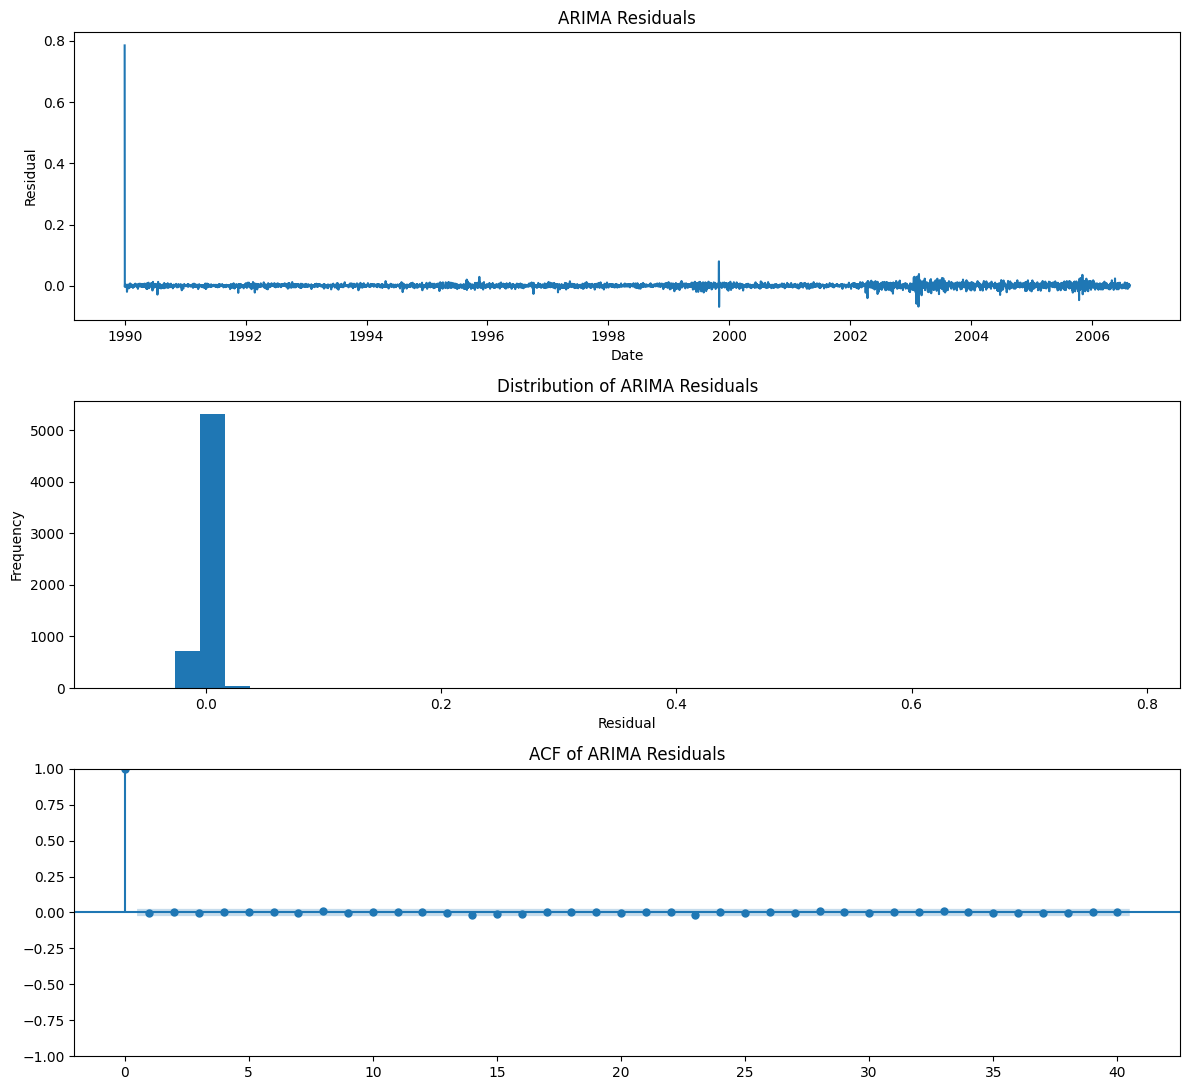

In [10]:
residuals = arima_fit.resid

fig, axes = plt.subplots(3, 1, figsize=(12, 11))

axes[0].plot(residuals)
axes[0].set_title("ARIMA Residuals")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals, bins=40)
axes[1].set_title("Distribution of ARIMA Residuals")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")

plot_acf(residuals.dropna(), lags=40, ax=axes[2])
axes[2].set_title("ACF of ARIMA Residuals")

plt.tight_layout()
plt.show()


In [11]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(residuals.dropna(), lags=[10, 20], return_df=True)
display(lb)


,lb_stat,lb_pvalue
10,1.023548,0.999809
20,5.300093,0.999565


# Part 3 – Exponential Smoothing

Exponential Smoothing gives more weight to recent observations.

Because this dataset is a single daily exchange-rate series and the assignment does not specify a known seasonal period, I compare:
- Simple Exponential Smoothing,
- Holt's trend method.

I do not impose a seasonal component without evidence of a stable seasonal pattern.


In [12]:
# Simple Exponential Smoothing
ses_model = SimpleExpSmoothing(train, initialization_method="estimated").fit(optimized=True)

# Holt's linear trend
holt_model = Holt(train, initialization_method="estimated").fit(optimized=True)

ses_forecast = ses_model.forecast(len(test))
holt_forecast = holt_model.forecast(len(test))

print("SES fitted.")
print("Holt fitted.")


SES fitted.
Holt fitted.


## 3.1 Exponential Smoothing model selection

For this assignment I treat the better-performing Exponential Smoothing variant as the representative model for comparison with ARIMA.

The test-set metrics below are calculated only after generating forecasts from the training period.


In [13]:
def forecast_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # Avoid division by zero in MAPE
    nonzero = actual != 0
    mape = np.mean(
        np.abs((actual[nonzero] - predicted[nonzero]) / actual[nonzero])
    ) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

ses_metrics = forecast_metrics(test, ses_forecast)
holt_metrics = forecast_metrics(test, holt_forecast)

es_comparison = pd.DataFrame([
    {"Model": "Simple Exponential Smoothing", **ses_metrics},
    {"Model": "Holt Exponential Smoothing", **holt_metrics}
])

display(es_comparison.round(6))

best_es_name = es_comparison.sort_values("RMSE").iloc[0]["Model"]
print("Best Exponential Smoothing variant by RMSE:", best_es_name)

best_es_forecast = ses_forecast if best_es_name == "Simple Exponential Smoothing" else holt_forecast


,Model,MAE,RMSE,MAPE (%)
0,Simple Exponential Smoothing,0.179046,0.206866,22.967915
1,Holt Exponential Smoothing,0.208249,0.240837,26.717611


Best Exponential Smoothing variant by RMSE: Simple Exponential Smoothing


# 4. Out-of-Sample Forecasting

The ARIMA forecast and the selected Exponential Smoothing forecast are compared with the actual test observations.

The forecast plot is important because numerical metrics alone do not show whether a model tracks turning points or systematically lags behind the actual series.


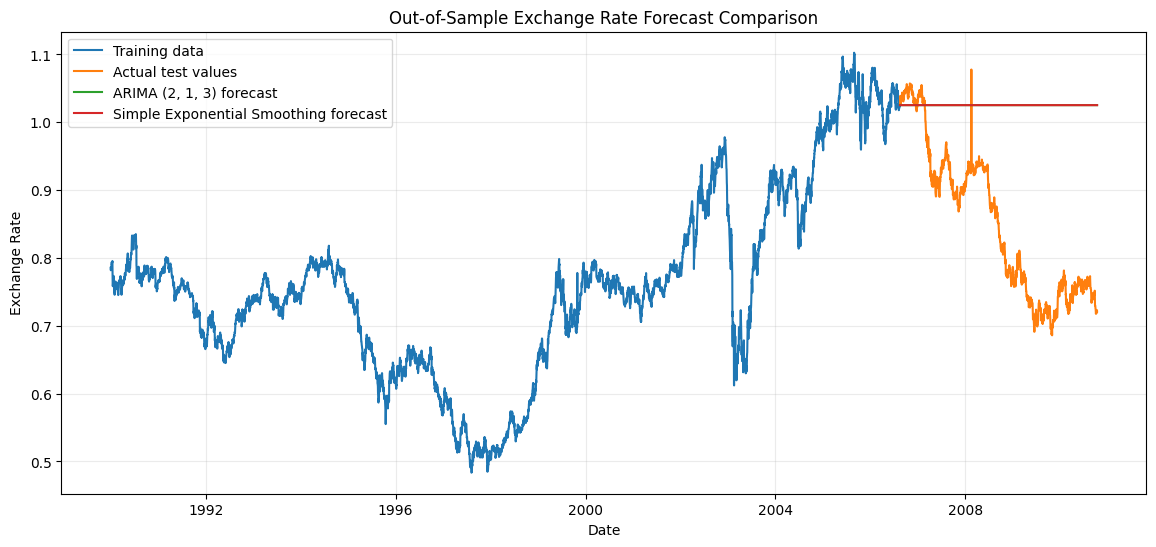

In [14]:
arima_forecast = arima_fit.forecast(steps=len(test))

plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label="Training data")
plt.plot(test.index, test.values, label="Actual test values")
plt.plot(test.index, arima_forecast.values, label=f"ARIMA {best_order} forecast")
plt.plot(test.index, best_es_forecast.values, label=best_es_name + " forecast")

plt.title("Out-of-Sample Exchange Rate Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# 5. Error Metrics

The assignment asks for:
- **MAE** – Mean Absolute Error
- **RMSE** – Root Mean Squared Error
- **MAPE** – Mean Absolute Percentage Error

For all three metrics, lower values indicate smaller forecasting errors.


,Model,MAE,RMSE,MAPE (%)
0,"ARIMA (2, 1, 3)",0.179059,0.206882,22.969641
1,Simple Exponential Smoothing,0.179046,0.206866,22.967915


<Figure size 1000x500 with 0 Axes>

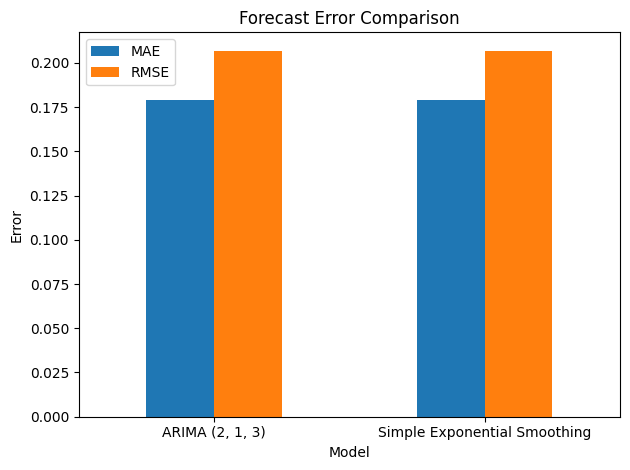

In [15]:
arima_metrics = forecast_metrics(test, arima_forecast)

final_comparison = pd.DataFrame([
    {"Model": f"ARIMA {best_order}", **arima_metrics},
    {"Model": best_es_name, **forecast_metrics(test, best_es_forecast)}
])

display(final_comparison.round(6))

plt.figure(figsize=(10, 5))
final_comparison.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar")
plt.title("Forecast Error Comparison")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 6. Model Comparison and Interpretation

### ARIMA

**Advantages**
- Explicitly models autoregressive and moving-average relationships.
- Differencing can make a non-stationary series suitable for modelling.
- ACF/PACF provide interpretable diagnostics for parameter selection.

**Limitations**
- Parameter selection can require experimentation.
- Forecast quality depends on whether the chosen ARIMA structure captures the dynamics of the exchange-rate series.
- Basic ARIMA does not automatically model changing volatility or external economic variables.

### Exponential Smoothing

**Advantages**
- Relatively simple and fast.
- Gives strong weight to recent observations.
- Often useful as a practical baseline for short-term forecasting.

**Limitations**
- Basic forms do not explicitly model autocorrelation in the same way as ARIMA.
- A simple trend model may miss complex dynamics.
- A seasonal component should only be added when the data supports a meaningful seasonal period.

### How to decide the better model

The model with the **lower MAE, RMSE and MAPE** performs better on the held-out test period. The final conclusion below is generated from the actual metrics calculated from this dataset rather than assuming in advance which method will win.


In [16]:
best_model_row = final_comparison.sort_values("RMSE").iloc[0]
best_model = best_model_row["Model"]

print("Best model by test-set RMSE:", best_model)
print("\nTest-set metrics for the best model:")
display(best_model_row.to_frame("Value"))


Best model by test-set RMSE: Simple Exponential Smoothing

Test-set metrics for the best model:


,Value
Model,Simple Exponential Smoothing
MAE,0.179046
RMSE,0.206866
MAPE (%),22.967915


# 7. Final Conclusion

1. The date column was parsed and used as the time index.
2. The series was explored visually for trend, seasonality and unusual movements.
3. Missing values were checked and handled where required.
4. ADF testing and first differencing were used to assess stationarity.
5. ACF and PACF plots were used to guide ARIMA parameter selection.
6. Several low-order ARIMA models were compared using AIC.
7. ARIMA residuals were diagnosed using residual plots, ACF and Ljung-Box testing.
8. Simple Exponential Smoothing and Holt's trend method were fitted.
9. The final comparison used a chronological 80/20 train-test split.
10. MAE, RMSE and MAPE were calculated on the out-of-sample test data.
11. Forecasts were plotted against the actual exchange rates.


